# Hyperparameter Optimization: 3D Printer Extrusion Quality## Grid Search, Random Search & Optuna**Project:** 010 — The AI Engineering Lab  **Objective:** Maximize 3D print quality by optimizing ML model hyperparameters.  **Advanced Concepts:** Grid vs Random convergence, Bayesian optimization, Optuna TPE sampler, parameter importance.

---## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

COLORS = {'primary': '#0D47A1', 'secondary': '#FF6F00', 'accent': '#2E7D32', 'highlight': '#C62828'}
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('Libraries loaded.')

Libraries loaded.


---## 2. Load Data

In [2]:
df = pd.read_csv('../data/3d_printer_quality.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (5000, 6)
Columns: ['nozzle_temp_c', 'print_speed_mm_s', 'layer_height_mm', 'cooling_fan_pct', 'retraction_mm', 'print_quality']


,nozzle_temp_c,print_speed_mm_s,layer_height_mm,cooling_fan_pct,retraction_mm,print_quality
0,236.6,87.5,0.103,37.4,7.33,0.5913
1,239.7,25.6,0.336,71.7,1.38,0.6513
2,187.5,77.3,0.158,42.9,5.05,0.7149
3,188.4,75.6,0.251,86.5,5.66,0.7196
4,209.4,119.1,0.107,82.1,5.71,0.3402


In [3]:
target_col = df.columns[-1]
feature_cols = [c for c in df.columns if c != target_col]
X = df[feature_cols].select_dtypes(include=[np.number])
y = df[target_col]
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print(f'Features ({len(feature_names)}): {feature_names}')
print(f'Target: {target_col}, mean={y.mean():.2f}')

Features (5): ['nozzle_temp_c', 'print_speed_mm_s', 'layer_height_mm', 'cooling_fan_pct', 'retraction_mm']
Target: print_quality, mean=0.64


---## 3. Baseline

In [4]:
baseline = GradientBoostingRegressor(random_state=42)
baseline.fit(X_train_s, y_train)
y_pred_base = baseline.predict(X_test_s)
base_r2 = r2_score(y_test, y_pred_base)
base_rmse = np.sqrt(mean_squared_error(y_test, y_pred_base))
print(f'Baseline GBR: R2={base_r2:.4f}, RMSE={base_rmse:.4f}')

Baseline GBR: R2=0.9704, RMSE=0.0316


---## 4. Grid Search

In [5]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}
grid = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid,
                    cv=3, scoring='r2', n_jobs=-1)
grid.fit(X_train_s, y_train)
y_pred_grid = grid.predict(X_test_s)
grid_r2 = r2_score(y_test, y_pred_grid)
grid_rmse = np.sqrt(mean_squared_error(y_test, y_pred_grid))
print(f'Grid Search: R2={grid_r2:.4f}, RMSE={grid_rmse:.4f}')
print(f'Best params: {grid.best_params_}')

Grid Search: R2=0.9733, RMSE=0.0300
Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


---## 5. Random Search

In [6]:
from scipy.stats import uniform, randint
param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(2, 8),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.6, 0.4)
}
random_search = RandomizedSearchCV(GradientBoostingRegressor(random_state=42), param_dist,
                                    n_iter=30, cv=3, scoring='r2', random_state=42, n_jobs=-1)
random_search.fit(X_train_s, y_train)
y_pred_rand = random_search.predict(X_test_s)
rand_r2 = r2_score(y_test, y_pred_rand)
rand_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rand))
print(f'Random Search: R2={rand_r2:.4f}, RMSE={rand_rmse:.4f}')
print(f'Best params: {random_search.best_params_}')

Random Search: R2=0.9732, RMSE=0.0301
Best params: {'learning_rate': np.float64(0.14606150771755597), 'max_depth': 2, 'n_estimators': 216, 'subsample': np.float64(0.6053059844639466)}


---## 6. Optuna (Bayesian Optimization)

In [7]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 2, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
    }
    model = GradientBoostingRegressor(**params, random_state=42)
    model.fit(X_train_s, y_train)
    return r2_score(y_test, model.predict(X_test_s))

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50)

best_model = GradientBoostingRegressor(**study.best_params, random_state=42)
best_model.fit(X_train_s, y_train)
y_pred_optuna = best_model.predict(X_test_s)
optuna_r2 = r2_score(y_test, y_pred_optuna)
optuna_rmse = np.sqrt(mean_squared_error(y_test, y_pred_optuna))
print(f'Optuna: R2={optuna_r2:.4f}, RMSE={optuna_rmse:.4f}')
print(f'Best params: {study.best_params}')

Optuna: R2=0.9741, RMSE=0.0295
Best params: {'n_estimators': 281, 'max_depth': 2, 'learning_rate': 0.14707929835943512, 'subsample': 0.8265463355178114}


---## 7. Comparison

       Method     R2   RMSE
     Baseline 0.9704 0.0316
  Grid Search 0.9733 0.0300
Random Search 0.9732 0.0301
 Optuna (TPE) 0.9741 0.0295


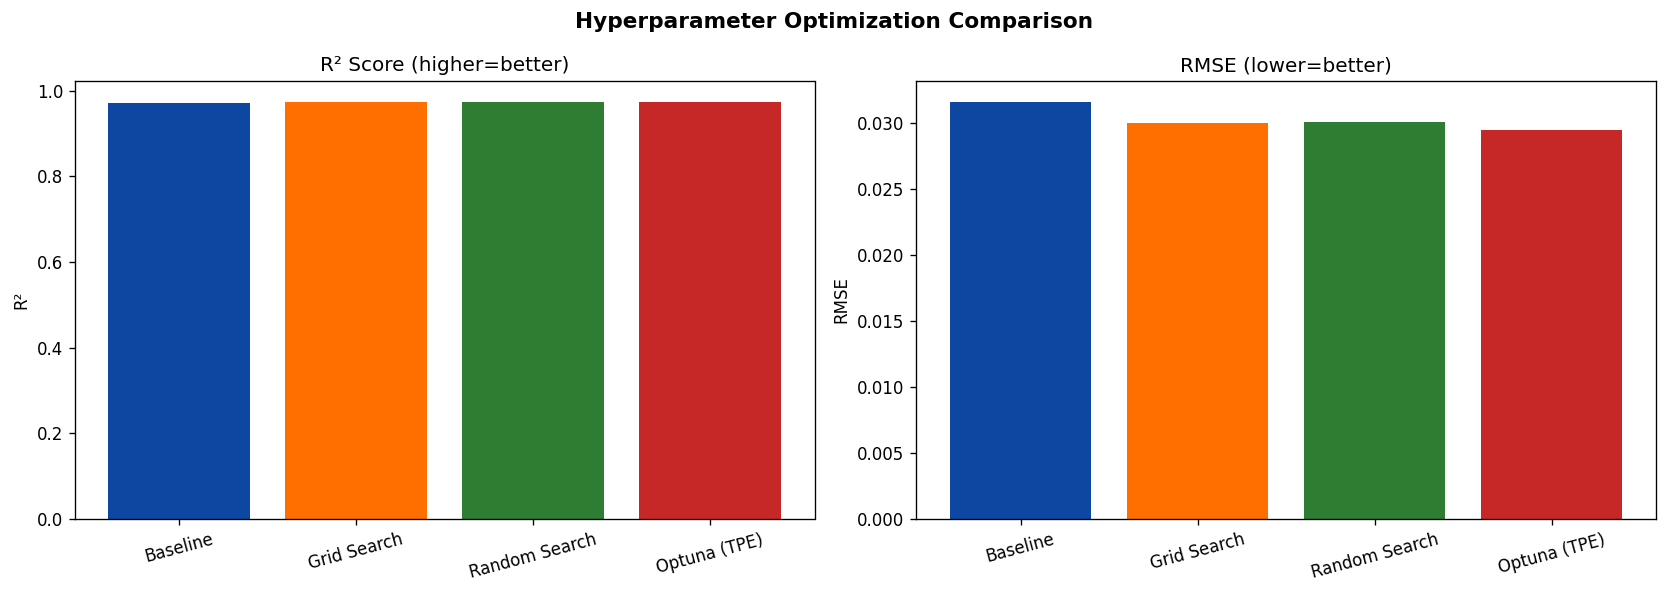

In [8]:
results = pd.DataFrame({
    'Method': ['Baseline', 'Grid Search', 'Random Search', 'Optuna (TPE)'],
    'R2': [base_r2, grid_r2, rand_r2, optuna_r2],
    'RMSE': [base_rmse, grid_rmse, rand_rmse, optuna_rmse]
}).round(4)
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = [COLORS['primary'], COLORS['secondary'], COLORS['accent'], COLORS['highlight']]
axes[0].bar(results['Method'], results['R2'], color=colors)
axes[0].set_title('R² Score (higher=better)'); axes[0].set_ylabel('R²')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=15)

axes[1].bar(results['Method'], results['RMSE'], color=colors)
axes[1].set_title('RMSE (lower=better)'); axes[1].set_ylabel('RMSE')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=15)

plt.suptitle('Hyperparameter Optimization Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/hpo_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

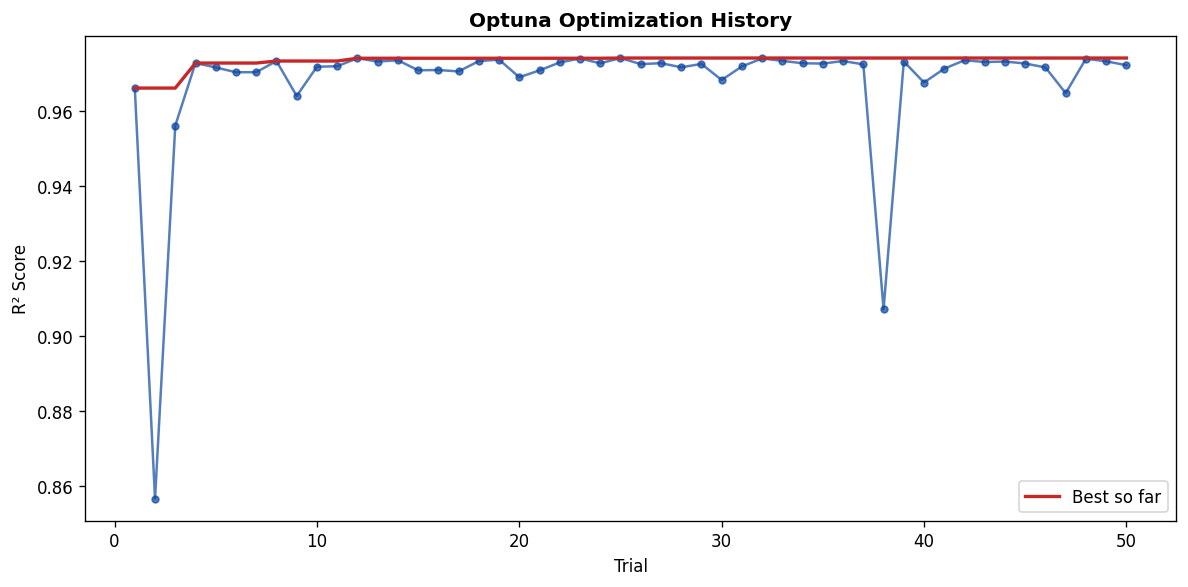

Notebook complete.


In [9]:
# Optuna optimization history
fig, ax = plt.subplots(figsize=(10, 5))
trials = [t.value for t in study.trials]
ax.plot(range(1, len(trials)+1), trials, 'o-', markersize=4, color=COLORS['primary'], alpha=0.7)
ax.plot(range(1, len(trials)+1), np.maximum.accumulate(trials), color=COLORS['highlight'], linewidth=2, label='Best so far')
ax.set_xlabel('Trial'); ax.set_ylabel('R² Score')
ax.set_title('Optuna Optimization History', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../assets/optuna_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Notebook complete.')